<a href="https://colab.research.google.com/github/doroteatomic/white-balancing-algorithms/blob/main/white_balancing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Instalacija i učitavanje dataset-a

In [87]:
!pip install kaggle

In [88]:
!wget https://zenodo.org/record/4153431/files/SimpleCube++.zip

--2026-03-22 19:46:33--  https://zenodo.org/record/4153431/files/SimpleCube++.zip
Resolving zenodo.org (zenodo.org)... 188.184.103.118, 188.185.48.75, 188.184.98.114, ...
Connecting to zenodo.org (zenodo.org)|188.184.103.118|:443... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/4153431/files/SimpleCube++.zip [following]
--2026-03-22 19:46:34--  https://zenodo.org/records/4153431/files/SimpleCube++.zip
Reusing existing connection to zenodo.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 2113441199 (2.0G) [application/octet-stream]
Saving to: ‘SimpleCube++.zip.1’

SimpleCube++.zip.1  100%[===================>]   1.97G  16.4MB/s    in 1m 48s  

2026-03-22 19:48:22 (18.6 MB/s) - ‘SimpleCube++.zip.1’ saved [2113441199/2113441199]



In [89]:
!unzip SimpleCube++.zip "SimpleCube++/test/*"

Archive:  SimpleCube++.zip
replace SimpleCube++/test/PNG/04_9463.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [90]:
!cp -r SimpleCube++/test .

In [91]:
import numpy as np
import cv2
import pandas as pd
import os
import matplotlib.pyplot as plt
from tqdm import tqdm

In [92]:
cam2rgb = np.array([
    1.8795, -1.0326,  0.1531,
   -0.2198,  1.7153, -0.4955,
    0.0069, -0.5150,  1.5081,
]).reshape((3, 3))

In [93]:
def load_image(path):

    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)   # 16-bit čitanje
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float64)

    black_lvl     = 2048
    saturation_lvl = 2**14 - 1
    img = np.clip((img - black_lvl) / (saturation_lvl - black_lvl), 0, 1)

    return img


In [94]:
def to_display(img):
    rgb = img.copy()
    rgb = np.clip(rgb, 0, 1)

    low  = np.percentile(rgb, 1)
    high = np.percentile(rgb, 99)
    rgb  = (rgb - low) / (high - low + 1e-6)
    rgb  = np.clip(rgb, 0, 1)

    rgb = rgb ** (1 / 2.2)

    return (rgb * 255).astype(np.uint8)

In [80]:
img = load_image("/content/SimpleCube++/test/PNG/00_0774.png")
print("R mean:", np.mean(img[:,:,0]))
print("G mean:", np.mean(img[:,:,1]))
print("B mean:", np.mean(img[:,:,2]))

R mean: 0.035926082521587674
G mean: 0.08306226360135494
B mean: 0.0576616902040612


# Algoritmi za white balancing

In [95]:
def gray_world_illum(img):
    """Gray World: iluminant = srednja vrijednost svakog kanala."""
    return np.mean(img, axis=(0, 1))

def shades_of_gray_illum(img, p=6):
    """Shades of Gray: iluminant = p-norma svakog kanala."""
    return np.power(np.mean(np.power(img, p), axis=(0, 1)), 1 / p)

# White Balance

In [96]:
def apply_wb(img, illum):

    # Normalizacija iluminanta
    illum_norm = illum / (np.sum(illum) + 1e-6)

    # White balance korekcija
    img_wb = np.clip(img / illum_norm, 0, 1)

    # Konverzija u RGB prostor
    rgb = np.dot(img_wb, cam2rgb.T)
    rgb = np.clip(rgb, 0, 1)

    # Contrast stretch
    low  = np.percentile(rgb, 1)
    high = np.percentile(rgb, 99)
    rgb  = (rgb - low) / (high - low + 1e-6)
    rgb  = np.clip(rgb, 0, 1)

    # Gamma korekcija
    rgb = rgb ** (1 / 2.0)

    return (rgb * 255).astype(np.uint8)

White Balance korekcija

Nakon procjene iluminanta potrebno je korigirati RGB vrijednosti slike kako bi iluminant postao neutralan. Korekcija se provodi prema formuli:

$$
I_{corrected} = I \cdot \frac{avg}{illum}
$$

gdje je:

- $I$ — originalna vrijednost piksela  
- $I_{corrected}$ — korigirana vrijednost piksela  
- $illum = (R, G, B)$ — procijenjeni iluminant  
- $avg$ — prosječna vrijednost iluminanta  

Prosjek iluminanta računa se kao:

$$
avg = \frac{R + G + B}{3}
$$

Na taj način skaliraju se RGB kanali slike tako da iluminant postane neutralno bijel, čime se uklanja dominantna boja osvjetljenja iz slike.

# Angular error (evaluacija)

In [97]:
def angular_error(est, gt):
    est = est / np.linalg.norm(est)
    gt  = gt  / np.linalg.norm(gt)
    dot = np.clip(np.dot(est, gt), -1, 1)
    return np.degrees(np.arccos(dot))

Za evaluaciju algoritama koristi se **kutna pogreška (angular error)** između procijenjenog iluminanta i stvarnog iluminanta iz dataset-a.

Formula je:

$$
error = \arccos \left( \frac{E_{est} \cdot E_{gt}}{|E_{est}| \, |E_{gt}|} \right)
$$

gdje je:

- $E_{est}$ — procijenjeni iluminant  
- $E_{gt}$ — stvarni (ground truth) iluminant iz dataset-a  
- $E_{est} \cdot E_{gt}$ — skalarni produkt vektora  
- $|E_{est}|$ i $|E_{gt}|$ — norme (duljine) vektora

Rezultat predstavlja kut između dva RGB vektora iluminanta u stupnjevima. Što je kut manji, to je procjena iluminanta točnija.

In [98]:
gt = pd.read_csv("/content/SimpleCube++/test/gt.csv")

gt_dict = {}
for _, row in gt.iterrows():
    filename = row["image"] + ".png"
    gt_dict[filename] = np.array([row["mean_r"], row["mean_g"], row["mean_b"]])

# Evaluacija

In [101]:
image_folder = "/content/SimpleCube++/test/PNG"

gw_errors = []
sg_errors = []

for filename in tqdm(os.listdir(image_folder)):
    if filename.endswith(".png"):
        path      = os.path.join(image_folder, filename)
        img       = load_image(path)
        gt_illum  = gt_dict[filename]

        gw_est = gray_world_illum(img)
        sg_est = shades_of_gray_illum(img, p=6)

        gw_errors.append(angular_error(gw_est, gt_illum))
        sg_errors.append(angular_error(sg_est, gt_illum))


100%|██████████| 462/462 [00:30<00:00, 14.98it/s]


In [102]:
print("Gray World   – srednja kutna pogreška:", np.mean(gw_errors))
print("Shades of Gray – srednja kutna pogreška:", np.mean(sg_errors))

Gray World   – srednja kutna pogreška: 3.4984961588678165
Shades of Gray – srednja kutna pogreška: 3.8594281776820374


# Vizualizacija

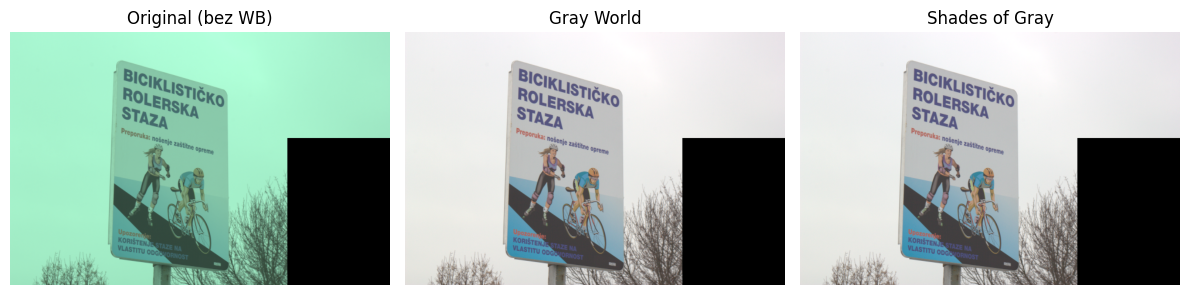

In [103]:
path = "/content/SimpleCube++/test/PNG/00_0774.png"
img  = load_image(path)

gw_illum = gray_world_illum(img)
sg_illum = shades_of_gray_illum(img)

img_orig = to_display(img)           # Original (bez WB)
img_gw   = apply_wb(img, gw_illum)   # Gray World WB
img_sg   = apply_wb(img, sg_illum)   # Shades of Gray WB

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_orig)
plt.title("Original (bez WB)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(img_gw)
plt.title("Gray World")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_sg)
plt.title("Shades of Gray")
plt.axis("off")

plt.tight_layout()
plt.show()

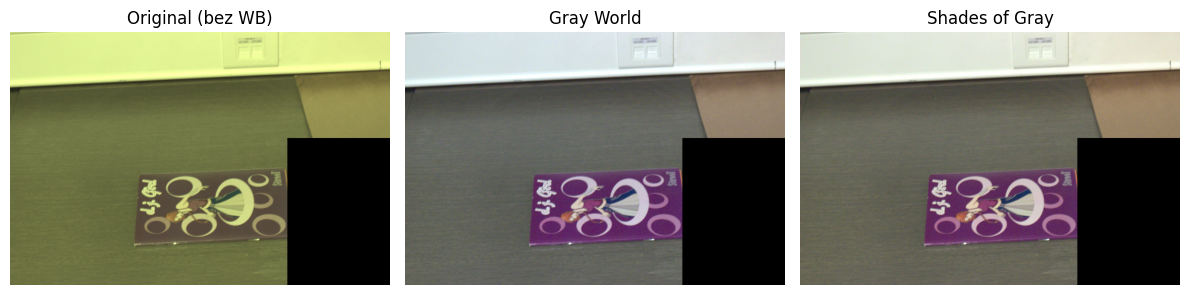

In [104]:
path = "/content/SimpleCube++/test/PNG/00_0905.png"
img  = load_image(path)

gw_illum = gray_world_illum(img)
sg_illum = shades_of_gray_illum(img)

img_orig = to_display(img)           # Original (bez WB)
img_gw   = apply_wb(img, gw_illum)   # Gray World WB
img_sg   = apply_wb(img, sg_illum)   # Shades of Gray WB

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_orig)
plt.title("Original (bez WB)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(img_gw)
plt.title("Gray World")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_sg)
plt.title("Shades of Gray")
plt.axis("off")

plt.tight_layout()
plt.show()

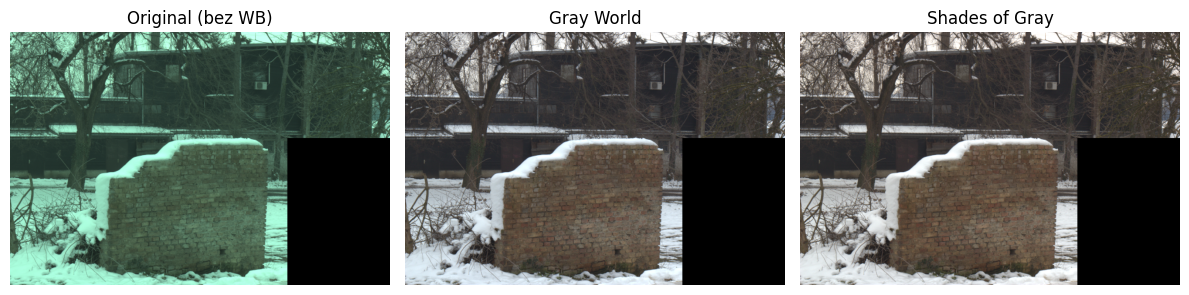

In [85]:
path = "/content/SimpleCube++/test/PNG/00_1317.png"
img  = load_image(path)

gw_illum = gray_world_illum(img)
sg_illum = shades_of_gray_illum(img)

img_orig = to_display(img)           # Original (bez WB)
img_gw   = apply_wb(img, gw_illum)   # Gray World WB
img_sg   = apply_wb(img, sg_illum)   # Shades of Gray WB

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_orig)
plt.title("Original (bez WB)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(img_gw)
plt.title("Gray World")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_sg)
plt.title("Shades of Gray")
plt.axis("off")

plt.tight_layout()
plt.show()

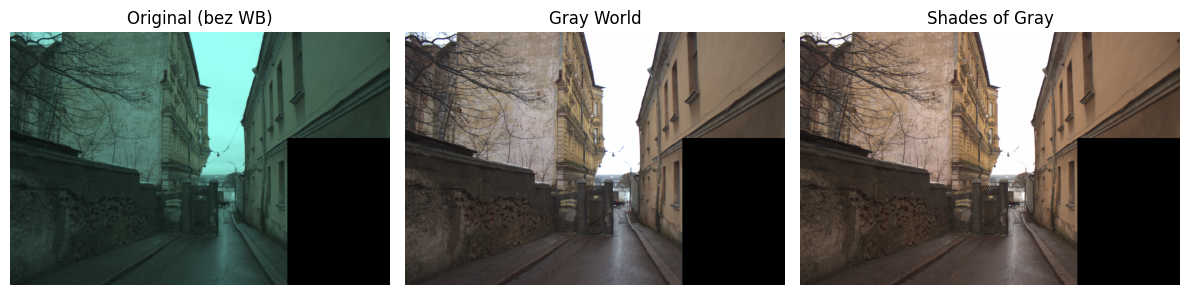

In [86]:
path = "/content/SimpleCube++/test/PNG/02_8262.png"
img  = load_image(path)

gw_illum = gray_world_illum(img)
sg_illum = shades_of_gray_illum(img)

img_orig = to_display(img)           # Original (bez WB)
img_gw   = apply_wb(img, gw_illum)   # Gray World WB
img_sg   = apply_wb(img, sg_illum)   # Shades of Gray WB

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_orig)
plt.title("Original (bez WB)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(img_gw)
plt.title("Gray World")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_sg)
plt.title("Shades of Gray")
plt.axis("off")

plt.tight_layout()
plt.show()